# imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("../General_Functions/")
from BasicData import *
from Flow_functions import * # import flow functions, Information to the agent
from Geometric_functions import * # Import rotation from euler angles
from Strategies_Evolution import * # Import strategies, Braitenberg or Triangulation
from Flow_functions import * # Import flow functions: stokeslet, grads, strains ... 

In [9]:
grad = GradientStresslet  # Note: it should work with a strain or another flow
grad_name = "GradientStresslet" # For saving porpouses
e = np.array([1, 0, 0])  # orientation of the flow
Nagent = 100  # number of agent positions (in the quarter circle of radius 1)
Npoints = 50 # Resolution of space sampling
Duration = 255 # Max number of timesteps in simulations
dt = .05 # timestep lenght
AntennaeLength = .01 # Half inter-sensors distance
roll = 0.3 # Rotation around swimming direction t
x = np.linspace(0.1, 5.5, Npoints) # x axis position of the agent
z = np.linspace(0.1, 5.5, Npoints) # z axis position of the agent
X, Z = np.meshgrid(x, z) # Create 2D grid
T_mean = np.zeros((Npoints, Npoints, 3))
Perf = np.zeros((Npoints, Npoints))

In [10]:

def Evolution(n, b, t, AgentPosition, AntennaeLength, FlowGradient, e3, dt, twist):
    
    # Flow measured in the cope reference system It is basically the triangulation in 3D
    x1 = AgentPosition + AntennaeLength*n
    x2 = AgentPosition - AntennaeLength*n
    Gradient_x1 = np.dot(FlowGradient(e3, x1), n)
    Gradient_x2 = np.dot(FlowGradient(e3, x2), n)
    
    TargetDirection = Triangulation3D(x1, Gradient_x1, x2, Gradient_x2)
    
    AngularSpeed =  np.cross(t, TargetDirection) 
    Norm = np.linalg.norm(AngularSpeed)  
    
    new_n = np.copy(n)
    new_b = np.copy(b)
    new_t = np.copy(t)
    
    Rotation = Quaternion(axis=AngularSpeed, angle=dt * Norm) 
    new_n = Rotation.rotate(n)
    new_b = Rotation.rotate(b)
    new_t = Rotation.rotate(t)

    # NEW ROTATION AROUND t (it allows all trajectories to converge towards spirals)
    Rotation_t = Quaternion(axis= new_t, angle = twist * dt)
    new_n = Rotation_t.rotate(new_n)
    new_b = Rotation_t.rotate(new_b)

    new_n /= np.linalg.norm(new_n)
    new_b /= np.linalg.norm(new_b)
    new_t /= np.linalg.norm(new_t)

    
    return new_n, new_b, new_t
    

In [11]:
# initialize 
t_T_end = np.zeros((Npoints, Npoints, Nagent, 3))
DotProductsNoRoll = np.zeros((Npoints, Npoints, Nagent))
DotProducts = np.zeros((Npoints, Npoints, Nagent))


for k in range(Npoints):
    for i in range(Npoints):
        AgentPosition =  np.array([z[k], x[i], 0.])
        OptimalDirection = -AgentPosition/np.linalg.norm(AgentPosition)
    
        for trials_i in range(Nagent):
            alpha, beta, gamma = (2 * np.random.rand(3) - 1) * np.pi
            R = Rotation(alpha, np.abs(beta), gamma)
            n_T = np.dot(R,[0, 1, 0])
            b_T = np.dot(R,[0, 0, 1])
            t_T = np.dot(R,[1, 0, 0])
    
            n_T_noroll = np.dot(R,[0, 1, 0])
            b_T_noroll = np.dot(R,[0, 0, 1])
            t_T_noroll = np.dot(R,[1, 0, 0])
           
            for time in range(Duration):
                n_T, b_T, t_T, _ = Evolution_Triangulation(n_T, b_T, t_T, AntennaeLength, AgentPosition, grad, e3, dt, V, roll)
                n_T_noroll, b_T_noroll, t_T_noroll, _ = Evolution_Triangulation(n_T_noroll, b_T_noroll, t_T_noroll, AntennaeLength, AgentPosition, grad, e3, dt, V, 0.0)
           
            t_T_end[k, i, trials_i, :] = t_T.copy()
            DotProducts[k, i, trials_i] = - np.dot(AgentPosition, t_T)
            DotProductsNoRoll[k, i, trials_i] = - np.dot(AgentPosition, t_T_noroll)
            

In [ ]:
# Compute Kullback-Leibler

In [7]:
# DotProductsNoRoll shape: (K, I, T)
K, I, T = DotProductsNoRoll.shape

N_bins = 50                    # number of bins for histogram estimation
eps = 1e-12                    # to avoid log(0)
KL_map = np.zeros((K, I))      # output

for k in range(K):
    for i in range(I):

        data = DotProductsNoRoll[k, i, :]
        # Build probability distribution of trials
        hist, _ = np.histogram(data, bins=N_bins, density=True)
        P = hist / np.sum(hist)        # normalize probability distribution

        # Uniform distribution with same support
        U = np.ones_like(P) / len(P)

        # KL divergence
        KL = np.sum(P * np.log((P + eps) / (U + eps)))
        KL_map[k, i] = KL

# plots

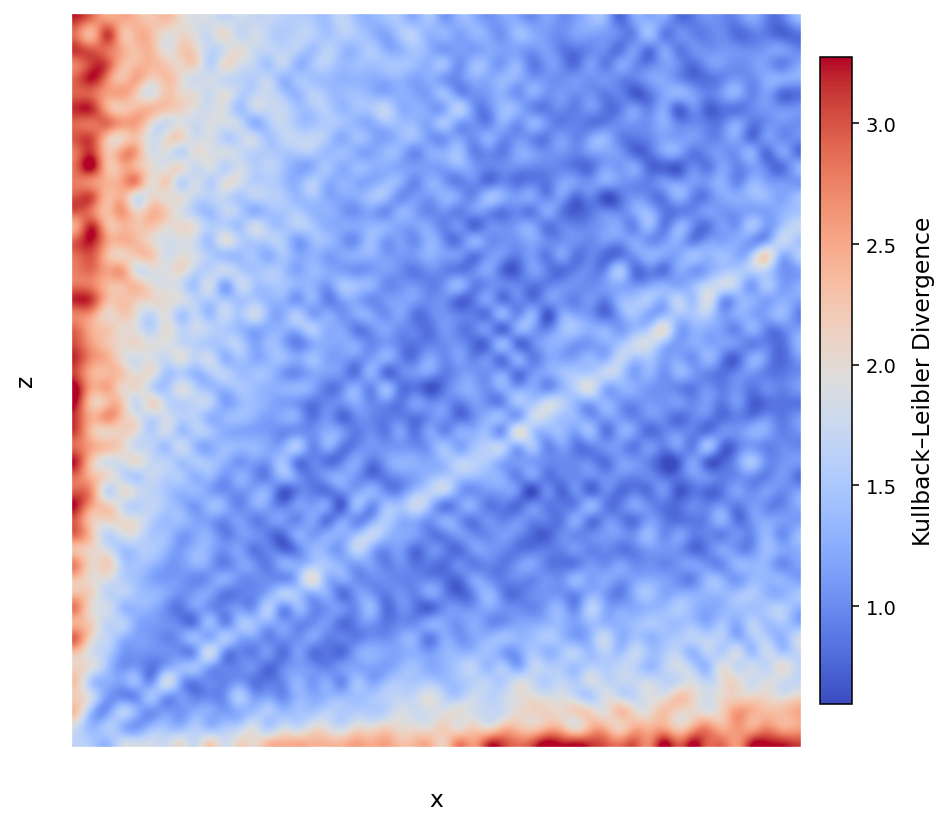

In [30]:

# Save data for reuse
np.save("KL_map_data.npy", KL_map)   #  <<--- requested data saving

# -------------------------------- Plot --------------------------------
fig, ax = plt.subplots(figsize=(7,6), dpi=140)

im = ax.imshow(KL_map,
               origin='lower',
               cmap="coolwarm",         # 🔥 visually powerful + divergence-friendly
               extent=[x.min(), x.max(), z.min(), z.max()],
               aspect='auto',
               interpolation="lanczos")   # smoother & high-quality rendering


cbar = fig.colorbar(im, shrink=0.88, pad=0.02)
cbar.set_label("Kullback–Leibler Divergence", fontsize=12, labelpad=8)
cbar.ax.tick_params(labelsize=10)

# Axis style
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("z", fontsize=12)

# Make borders + grid subtle
for spine in ax.spines.values():
    spine.set_linewidth(1.2)
    spine.set_color("white")

ax.tick_params(colors="white", labelsize=10)
ax.set_facecolor("black")   # contrast pop

plt.tight_layout()
plt.savefig('ImshowKLDistanceStresslet.png')
plt.show()
# -------------------------------

C:\Users\Redaelli\AppData\Local\Temp\ipykernel_7136\3697942130.py:3: UserWarning: The following kwargs were not used by contour: 'level'
  im = plt.contourf(X, Z, KL_map, level = 50)


AttributeError: module 'matplotlib.pyplot' has no attribute 'save'

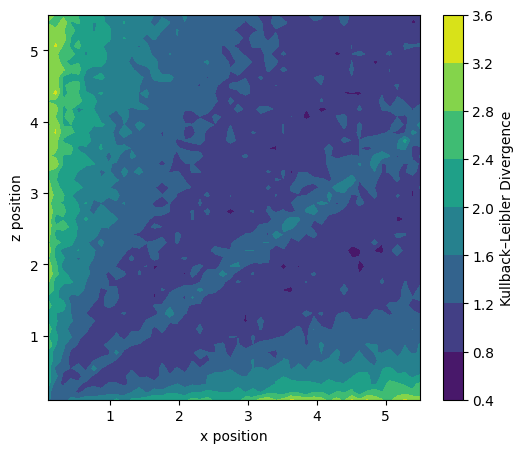

In [26]:
# ---- PLOT ----
plt.figure(figsize=(6,5))
KL_map = np.load("KL_map.npy")
im = plt.contourf(X, Z, KL_map, level = 50)

plt.colorbar(im, label='Kullback–Leibler Divergence')
plt.xlabel("x position")
plt.ylabel("z position")
#plt.title("KL divergence between DotProducts distribution and uniform distribution")
plt.save
plt.show()